# Cognifyz Technologies - Data Science Internship
## Level 2: Table Booking & Online Delivery, Price Range Analysis, Feature Engineering

**Make sure `Dataset_.csv` is in the same folder as this notebook before running.**

## Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
%matplotlib inline

## Load the Dataset

In [2]:
df = pd.read_csv("Dataset_.csv")
df["Cuisines"] = df["Cuisines"].fillna("Not Available")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
## Task 1: Table Booking and Online Delivery
### 1.1 Percentage of restaurants offering table booking / online delivery

In [3]:
table_booking_pct = (df["Has Table booking"] == "Yes").mean() * 100
online_delivery_pct = (df["Has Online delivery"] == "Yes").mean() * 100

print(f"Restaurants offering Table Booking  : {table_booking_pct:.2f}%")
print(f"Restaurants offering Online Delivery: {online_delivery_pct:.2f}%")

Restaurants offering Table Booking  : 12.12%
Restaurants offering Online Delivery: 25.66%


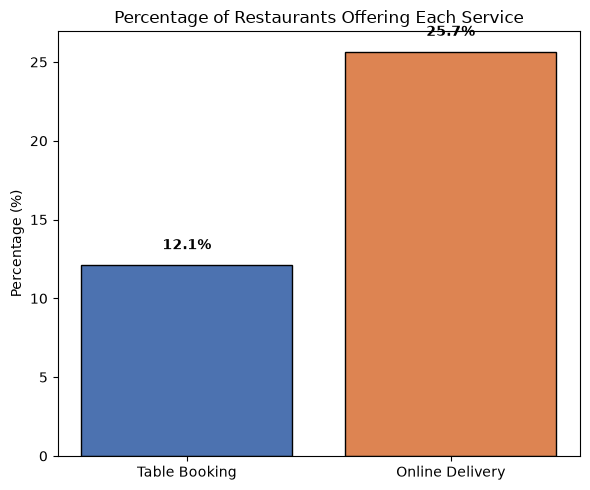

In [4]:
plt.figure(figsize=(6, 5))
plt.bar(["Table Booking", "Online Delivery"], [table_booking_pct, online_delivery_pct],
        color=["#4C72B0", "#DD8452"], edgecolor="black")
plt.title("Percentage of Restaurants Offering Each Service")
plt.ylabel("Percentage (%)")
for i, v in enumerate([table_booking_pct, online_delivery_pct]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.2 Compare average ratings: table booking vs no table booking

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


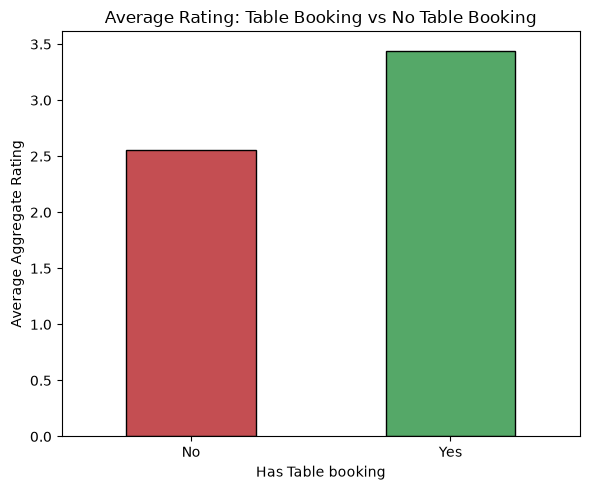

In [5]:
avg_rating_booking = df.groupby("Has Table booking")["Aggregate rating"].mean()
print(avg_rating_booking)

plt.figure(figsize=(6, 5))
avg_rating_booking.plot(kind="bar", color=["#C44E52", "#55A868"], edgecolor="black")
plt.title("Average Rating: Table Booking vs No Table Booking")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Restaurants with table booking tend to have higher average ratings, likely reflecting more established, higher-quality establishments.

### 1.3 Online delivery availability across price ranges

Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


<Figure size 700x500 with 0 Axes>

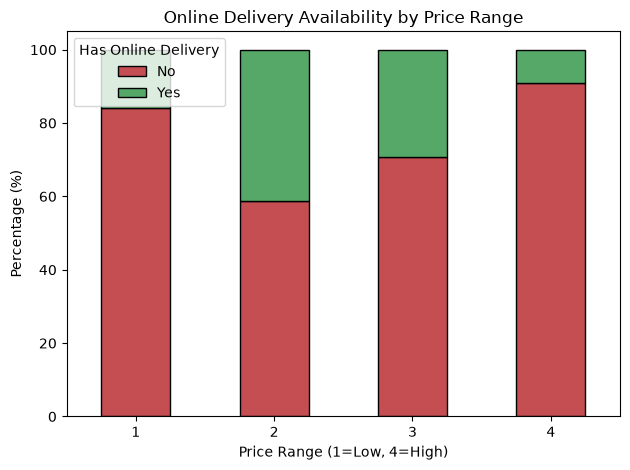

In [6]:
delivery_by_price = pd.crosstab(df["Price range"], df["Has Online delivery"], normalize="index") * 100
print(delivery_by_price)

plt.figure(figsize=(7, 5))
delivery_by_price.plot(kind="bar", stacked=True, color=["#C44E52", "#55A868"], edgecolor="black")
plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range (1=Low, 4=High)")
plt.ylabel("Percentage (%)")
plt.legend(title="Has Online Delivery")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Online delivery is most common among lower-to-mid price-range restaurants and least common at the highest price range (4).

---
## Task 2: Price Range Analysis
### 2.1 Most common price range

In [7]:
price_range_counts = df["Price range"].value_counts().sort_index()
print(price_range_counts)

most_common_price_range = price_range_counts.idxmax()
print(f"\nMost common price range: {most_common_price_range} ({price_range_counts.max()} restaurants)")

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Most common price range: 1 (4444 restaurants)


### 2.2 Average rating for each price range

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


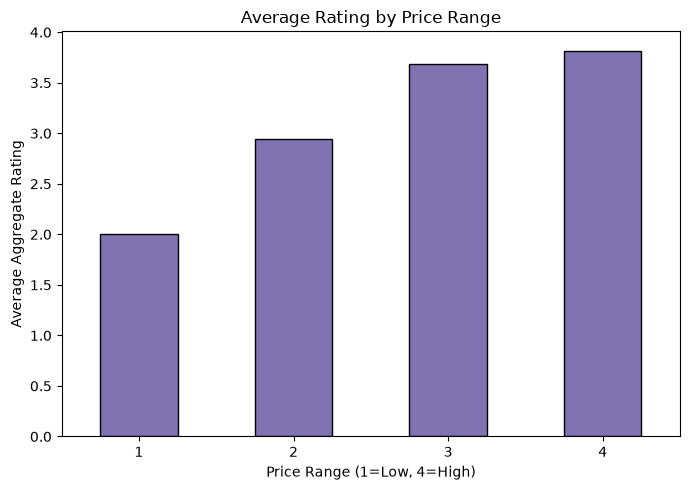

In [8]:
avg_rating_by_price = df.groupby("Price range")["Aggregate rating"].mean()
print(avg_rating_by_price)

plt.figure(figsize=(7, 5))
avg_rating_by_price.plot(kind="bar", color="#8172B2", edgecolor="black")
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range (1=Low, 4=High)")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.3 Color representing the highest average rating

In [9]:
color_rating = df.groupby("Rating color")["Aggregate rating"].mean().sort_values(ascending=False)
print(color_rating)

top_color = color_rating.idxmax()
print(f"\nColor representing the highest average rating: '{top_color}' (avg = {color_rating.max():.2f})")

Rating color
Dark Green    4.659801
Green         4.168119
Yellow        3.683429
Orange        3.051619
Red           2.297849
White         0.000000
Name: Aggregate rating, dtype: float64

Color representing the highest average rating: 'Dark Green' (avg = 4.66)


**Observation:** Average rating increases with price range, peaking at price range 4. 'Dark Green' is the color associated with the highest-rated restaurants.

---
## Task 3: Feature Engineering
### 3.1 Extract length-based features

In [10]:
df["Restaurant Name Length"] = df["Restaurant Name"].str.len()
df["Address Length"] = df["Address"].str.len()

df[["Restaurant Name", "Restaurant Name Length", "Address", "Address Length"]].head()

,Restaurant Name,Restaurant Name Length,Address,Address Length
0,Le Petit Souffle,16,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,Izakaya Kikufuji,16,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,Heat - Edsa Shangri-La,22,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,Ooma,4,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,Sambo Kojin,11,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [11]:
print(df["Restaurant Name Length"].describe())
print()
print(df["Address Length"].describe())

count    9551.000000
mean       15.164171
std         6.858392
min         2.000000
25%        10.000000
50%        14.000000
75%        19.000000
max        54.000000
Name: Restaurant Name Length, dtype: float64

count    9551.000000
mean       53.536698
std        17.122035
min        13.000000
25%        41.000000
50%        52.000000
75%        64.000000
max       132.000000
Name: Address Length, dtype: float64


### 3.2 Encode categorical Yes/No variables into binary features

In [12]:
df["Has Table Booking (binary)"] = df["Has Table booking"].map({"Yes": 1, "No": 0})
df["Has Online Delivery (binary)"] = df["Has Online delivery"].map({"Yes": 1, "No": 0})

df[["Has Table booking", "Has Table Booking (binary)",
    "Has Online delivery", "Has Online Delivery (binary)"]].head()

,Has Table booking,Has Table Booking (binary),Has Online delivery,Has Online Delivery (binary)
0,Yes,1,No,0
1,Yes,1,No,0
2,Yes,1,No,0
3,No,0,No,0
4,Yes,1,No,0


In [13]:
print(df["Has Table Booking (binary)"].value_counts())
print()
print(df["Has Online Delivery (binary)"].value_counts())

Has Table Booking (binary)
0    8393
1    1158
Name: count, dtype: int64

Has Online Delivery (binary)
0    7100
1    2451
Name: count, dtype: int64


### 3.3 Save engineered features

In [14]:
engineered_cols = ["Restaurant Name", "Restaurant Name Length", "Address Length",
                    "Has Table Booking (binary)", "Has Online Delivery (binary)",
                    "Aggregate rating"]
df[engineered_cols].to_csv("task3_engineered_features.csv", index=False)
print("Saved: task3_engineered_features.csv")

Saved: task3_engineered_features.csv


---
### Level 2 Complete!